# SK하이닉스 / S&P 500 주가 트렌드 분석 (2025.1 - 2026.8.31)

> AI·HBM 수요 폭증 시대, 반도체 대표주 SK하이닉스와 글로벌 대표 지수 S&P 500의 비교 분석

- **데이터 출처**: Yahoo Finance (yfinance)
- **분석 기간**: 2025-01-02 ~ 2026-08-31


## 0. 환경 설정

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import STL
import warnings, os
warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
os.makedirs("data", exist_ok=True)
os.makedirs("images", exist_ok=True)
COLOR_HYX, COLOR_SP = "#E65100", "#1565C0"
print("환경 설정 완료")

환경 설정 완료


## 1. 데이터 수집 및 로드 (2025.01 ~ 2026.08.31)

In [2]:
# 2025-01-01부터 2026-08-31까지 데이터 로드
hyx = pd.read_csv("data/skhynix_2025_2026.csv", index_col=0, parse_dates=True)
sp  = pd.read_csv("data/sp500_2025_2026.csv",   index_col=0, parse_dates=True)
if isinstance(hyx.columns, pd.MultiIndex): hyx.columns = hyx.columns.get_level_values(0)
if isinstance(sp.columns,  pd.MultiIndex): sp.columns  = sp.columns.get_level_values(0)
hyx_close = hyx["Close"].dropna()
sp_close  = sp["Close"].dropna()
print(f"SK하이닉스: {hyx_close.index.min().date()} ~ {hyx_close.index.max().date()}, 총 {len(hyx_close)}거래일")
print(f"S&P 500   : {sp_close.index.min().date()} ~ {sp_close.index.max().date()}, 총 {len(sp_close)}거래일")

SK하이닉스: 2025-01-02 ~ 2026-08-31, 총 403거래일
S&P 500   : 2025-01-02 ~ 2026-08-31, 총 416거래일


## 2. 데이터 탐색 — 결측치 확인

In [3]:
print("=== SK하이닉스 결측치 ===")
print(hyx.isnull().sum())
print("
=== S&P 500 결측치 ===")
print(sp.isnull().sum())

=== SK하이닉스 결측치 ===
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

=== S&P 500 결측치 ===
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


## 3. 파생 지표 계산 (정규화, 이동평균, 일일/월별/분기별 수익률)

In [4]:
hyx_norm = hyx_close / hyx_close.iloc[0] * 100
sp_norm  = sp_close  / sp_close.iloc[0]  * 100
hyx_ma20 = hyx_close.rolling(20).mean()
hyx_ma60 = hyx_close.rolling(60).mean()
hyx_ret  = hyx_close.pct_change() * 100
sp_ret   = sp_close.pct_change()  * 100
print("파생 지표(정규화, 이동평균, 수익률) 계산 완료")

파생 지표(정규화, 이동평균, 수익률) 계산 완료


## 4. 시각화 1 — 가격 추이 비교 및 이중 축 스케일 보정 (필수 ①)

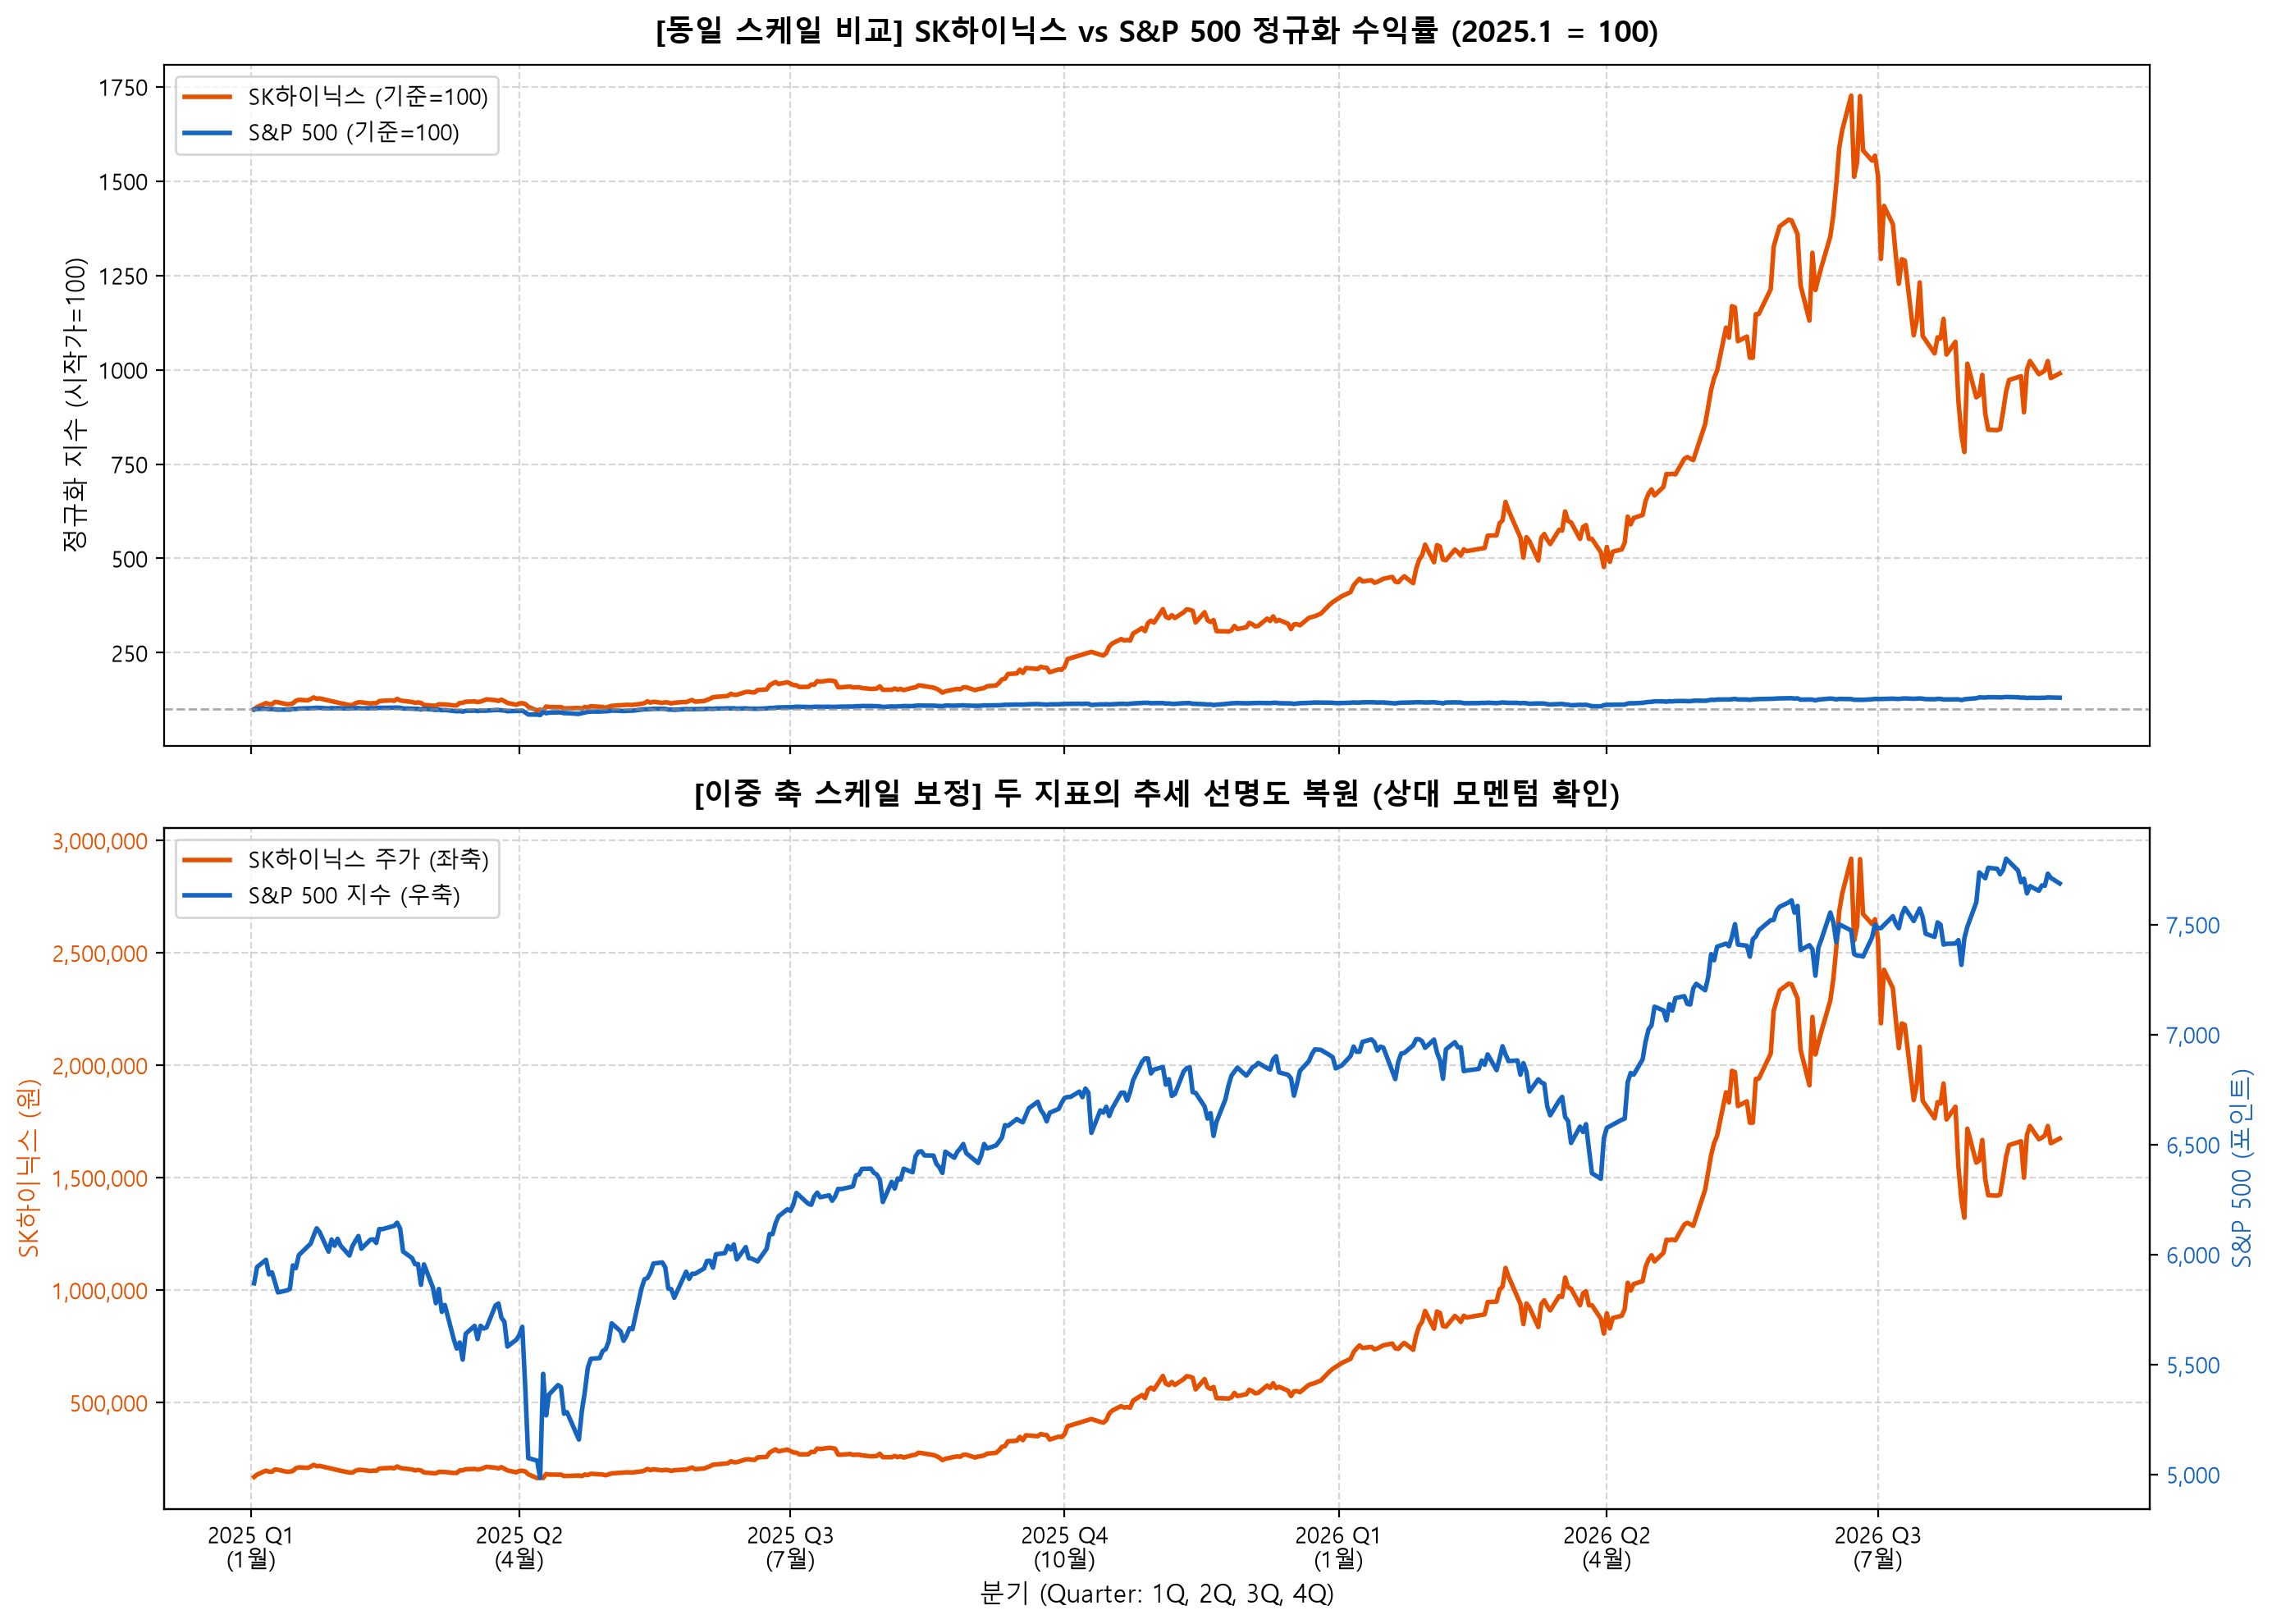

In [5]:
def format_quarter(x, pos=None):
    dt = mdates.num2date(x)
    q = (dt.month - 1) // 3 + 1
    return f"{dt.year} Q{q}\n({dt.month}월)"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# 상단: 동일 100 기준
ax1.plot(hyx_norm.index, hyx_norm.values, color=COLOR_HYX, linewidth=2.0, label="SK하이닉스 (기준=100)")
ax1.plot(sp_norm.index,  sp_norm.values,  color=COLOR_SP,  linewidth=2.0, label="S&P 500 (기준=100)")
ax1.axhline(100, color="#888888", linewidth=1.0, linestyle="--", alpha=0.7)
ax1.set_title("[동일 스케일 비교] SK하이닉스 vs S&P 500 정규화 수익률 (2025.1 = 100)", fontsize=13, fontweight="bold")
ax1.set_ylabel("정규화 지수 (시작가=100)")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left")

# 하단: 이중 축 보정
ax2_l = ax2
ax2_r = ax2.twinx()
l1 = ax2_l.plot(hyx_close.index, hyx_close.values, color=COLOR_HYX, linewidth=2.0, label="SK하이닉스 주가 (좌축)")
l2 = ax2_r.plot(sp_close.index,  sp_close.values,  color=COLOR_SP,  linewidth=2.0, label="S&P 500 지수 (우축)")
ax2_l.set_title("[이중 축 스케일 보정] 두 지표의 추세 선명도 복원", fontsize=13, fontweight="bold")
ax2_l.set_ylabel("SK하이닉스 (원)", color=COLOR_HYX)
ax2_r.set_ylabel("S&P 500 (포인트)", color=COLOR_SP)
ax2_l.tick_params(axis="y", labelcolor=COLOR_HYX)
ax2_r.tick_params(axis="y", labelcolor=COLOR_SP)
ax2_l.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))
ax2_r.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))
ax2_l.grid(True, linestyle="--", alpha=0.5)

lines = l1 + l2
ax2_l.legend(lines, [l.get_label() for l in lines], loc="upper left")
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax2.xaxis.set_major_formatter(plt.FuncFormatter(format_quarter))
ax2.set_xlabel("분기 (Quarter: 1Q, 2Q, 3Q, 4Q)")

plt.tight_layout()
plt.savefig("images/01_price_trend.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. 시각화 2 — SK하이닉스 이동평균(20일·60일) 및 골든/데드크로스 (필수 ②)

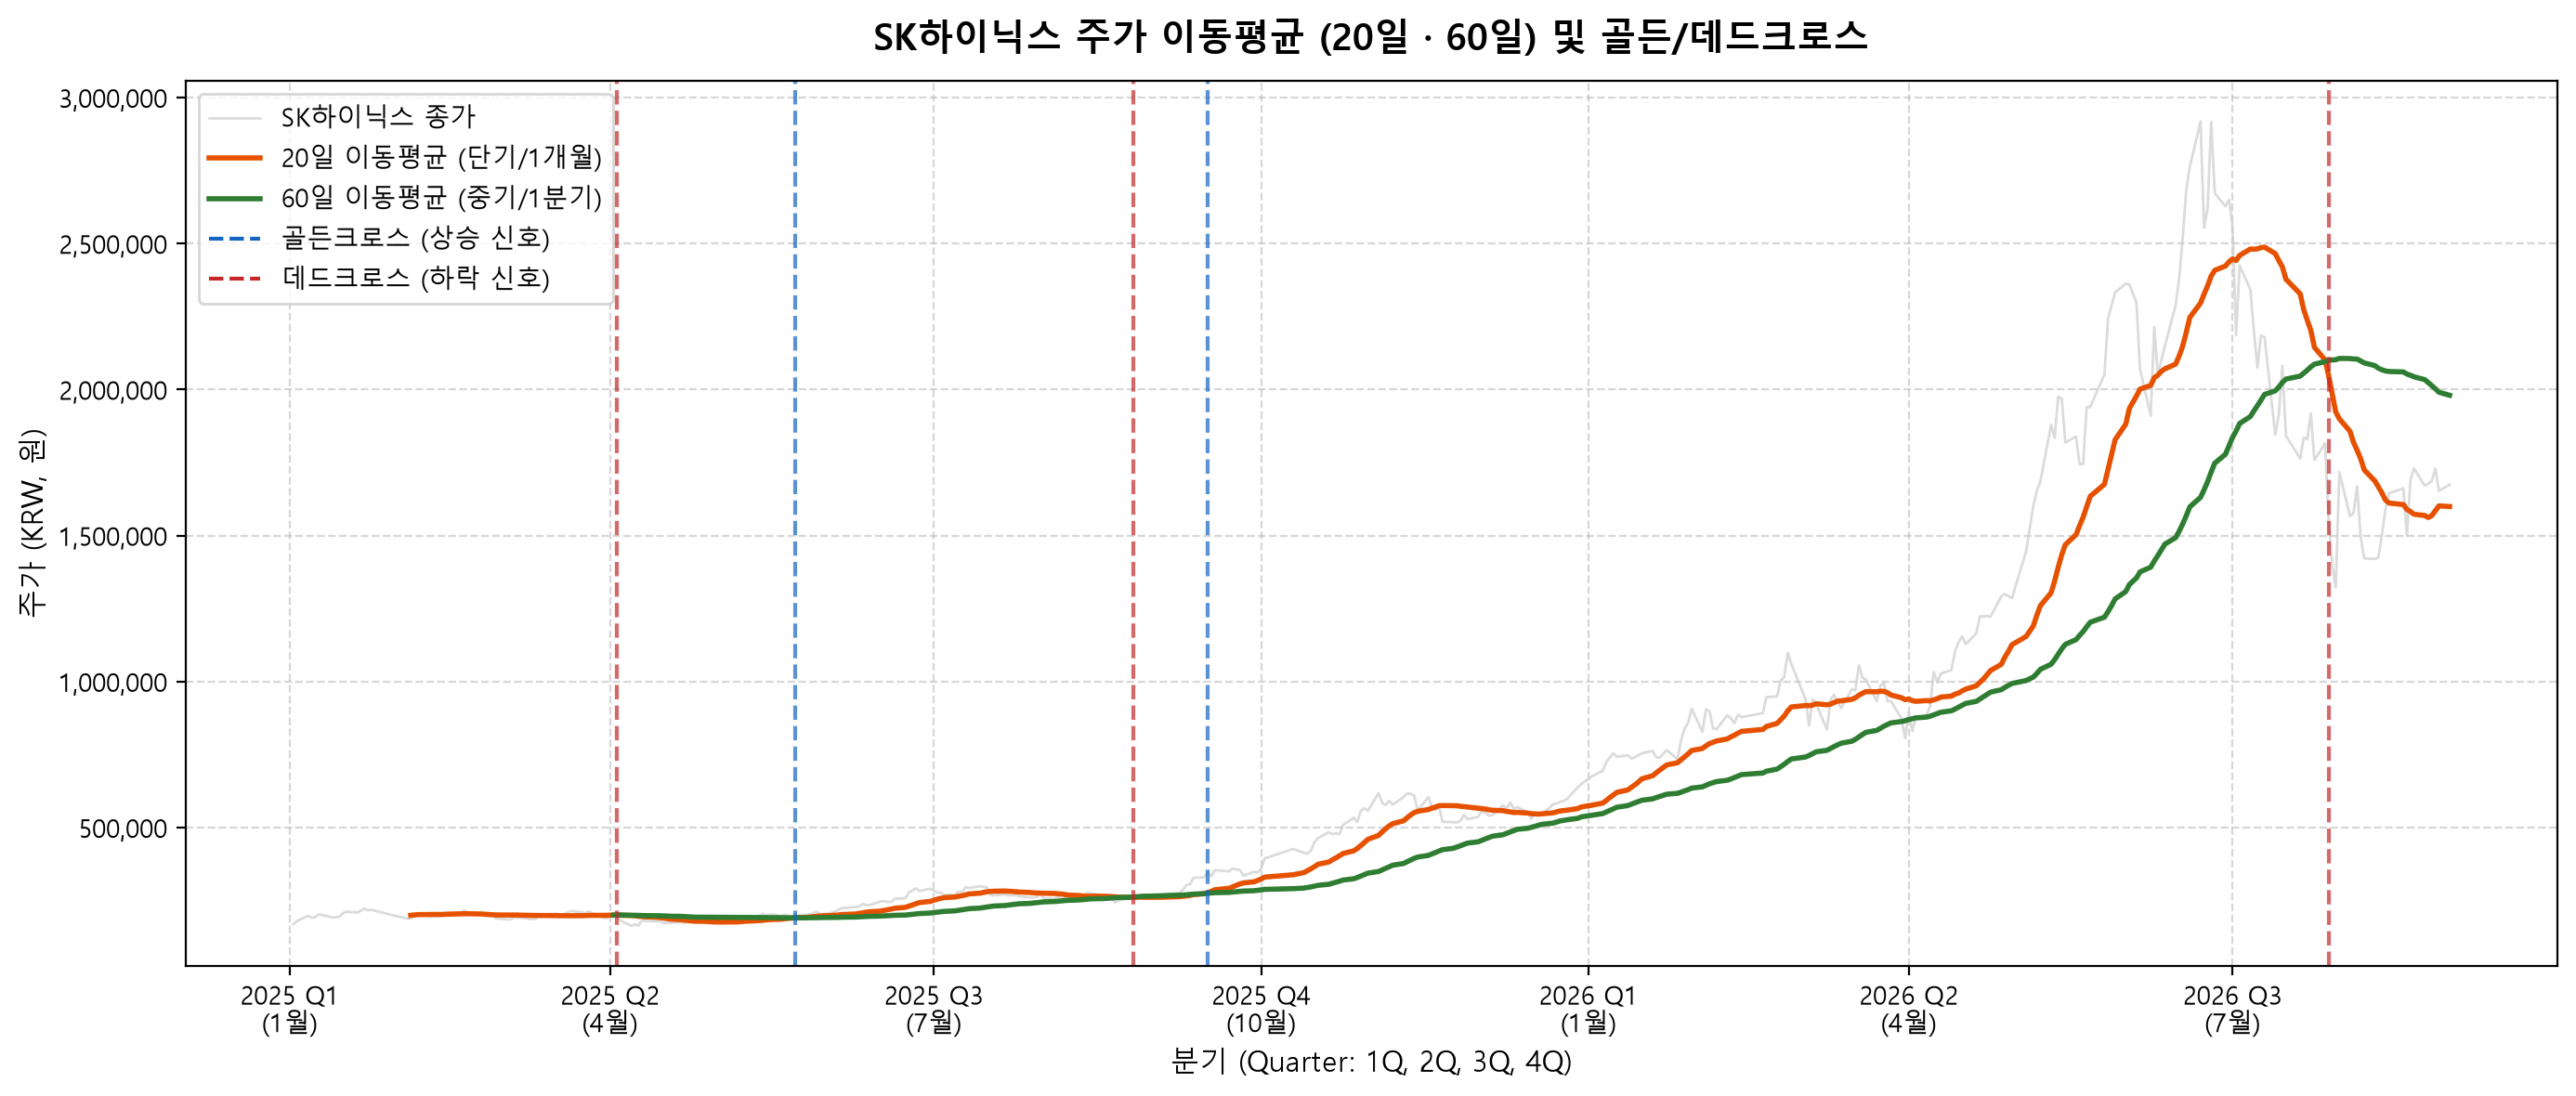

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(hyx_close.index, hyx_close.values, color="#CCCCCC", linewidth=1.0, alpha=0.7, label="SK하이닉스 종가")
ax.plot(hyx_ma20.index,  hyx_ma20.values,  color=COLOR_HYX, linewidth=2.0, label="20일 이동평균 (단기)")
ax.plot(hyx_ma60.index,  hyx_ma60.values,  color="#2E7D32", linewidth=2.0, label="60일 이동평균 (중기)")

golden = (hyx_ma20 > hyx_ma60) & (hyx_ma20.shift(1) <= hyx_ma60.shift(1))
dead   = (hyx_ma20 < hyx_ma60) & (hyx_ma20.shift(1) >= hyx_ma60.shift(1))

for d in hyx_close.index[golden]: ax.axvline(d, color="#1565C0", linewidth=1.5, linestyle="--", alpha=0.7)
for d in hyx_close.index[dead]:  ax.axvline(d, color="#C62828", linewidth=1.5, linestyle="--", alpha=0.7)

ax.plot([], [], color="#1565C0", linestyle="--", label="골든크로스 (상승 신호)")
ax.plot([], [], color="#C62828", linestyle="--", label="데드크로스 (하락 신호)")

ax.set_title("SK하이닉스 주가 이동평균 (20일 · 60일) 및 골든/데드크로스", fontsize=14, fontweight="bold")
ax.set_xlabel("분기 (Quarter: 1Q, 2Q, 3Q, 4Q)")
ax.set_ylabel("주가 (KRW, 원)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(plt.FuncFormatter(format_quarter))
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("images/02_moving_average.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. 시각화 3 — 분기별 성과 및 월별 수익률 히트맵 (권장 ③)

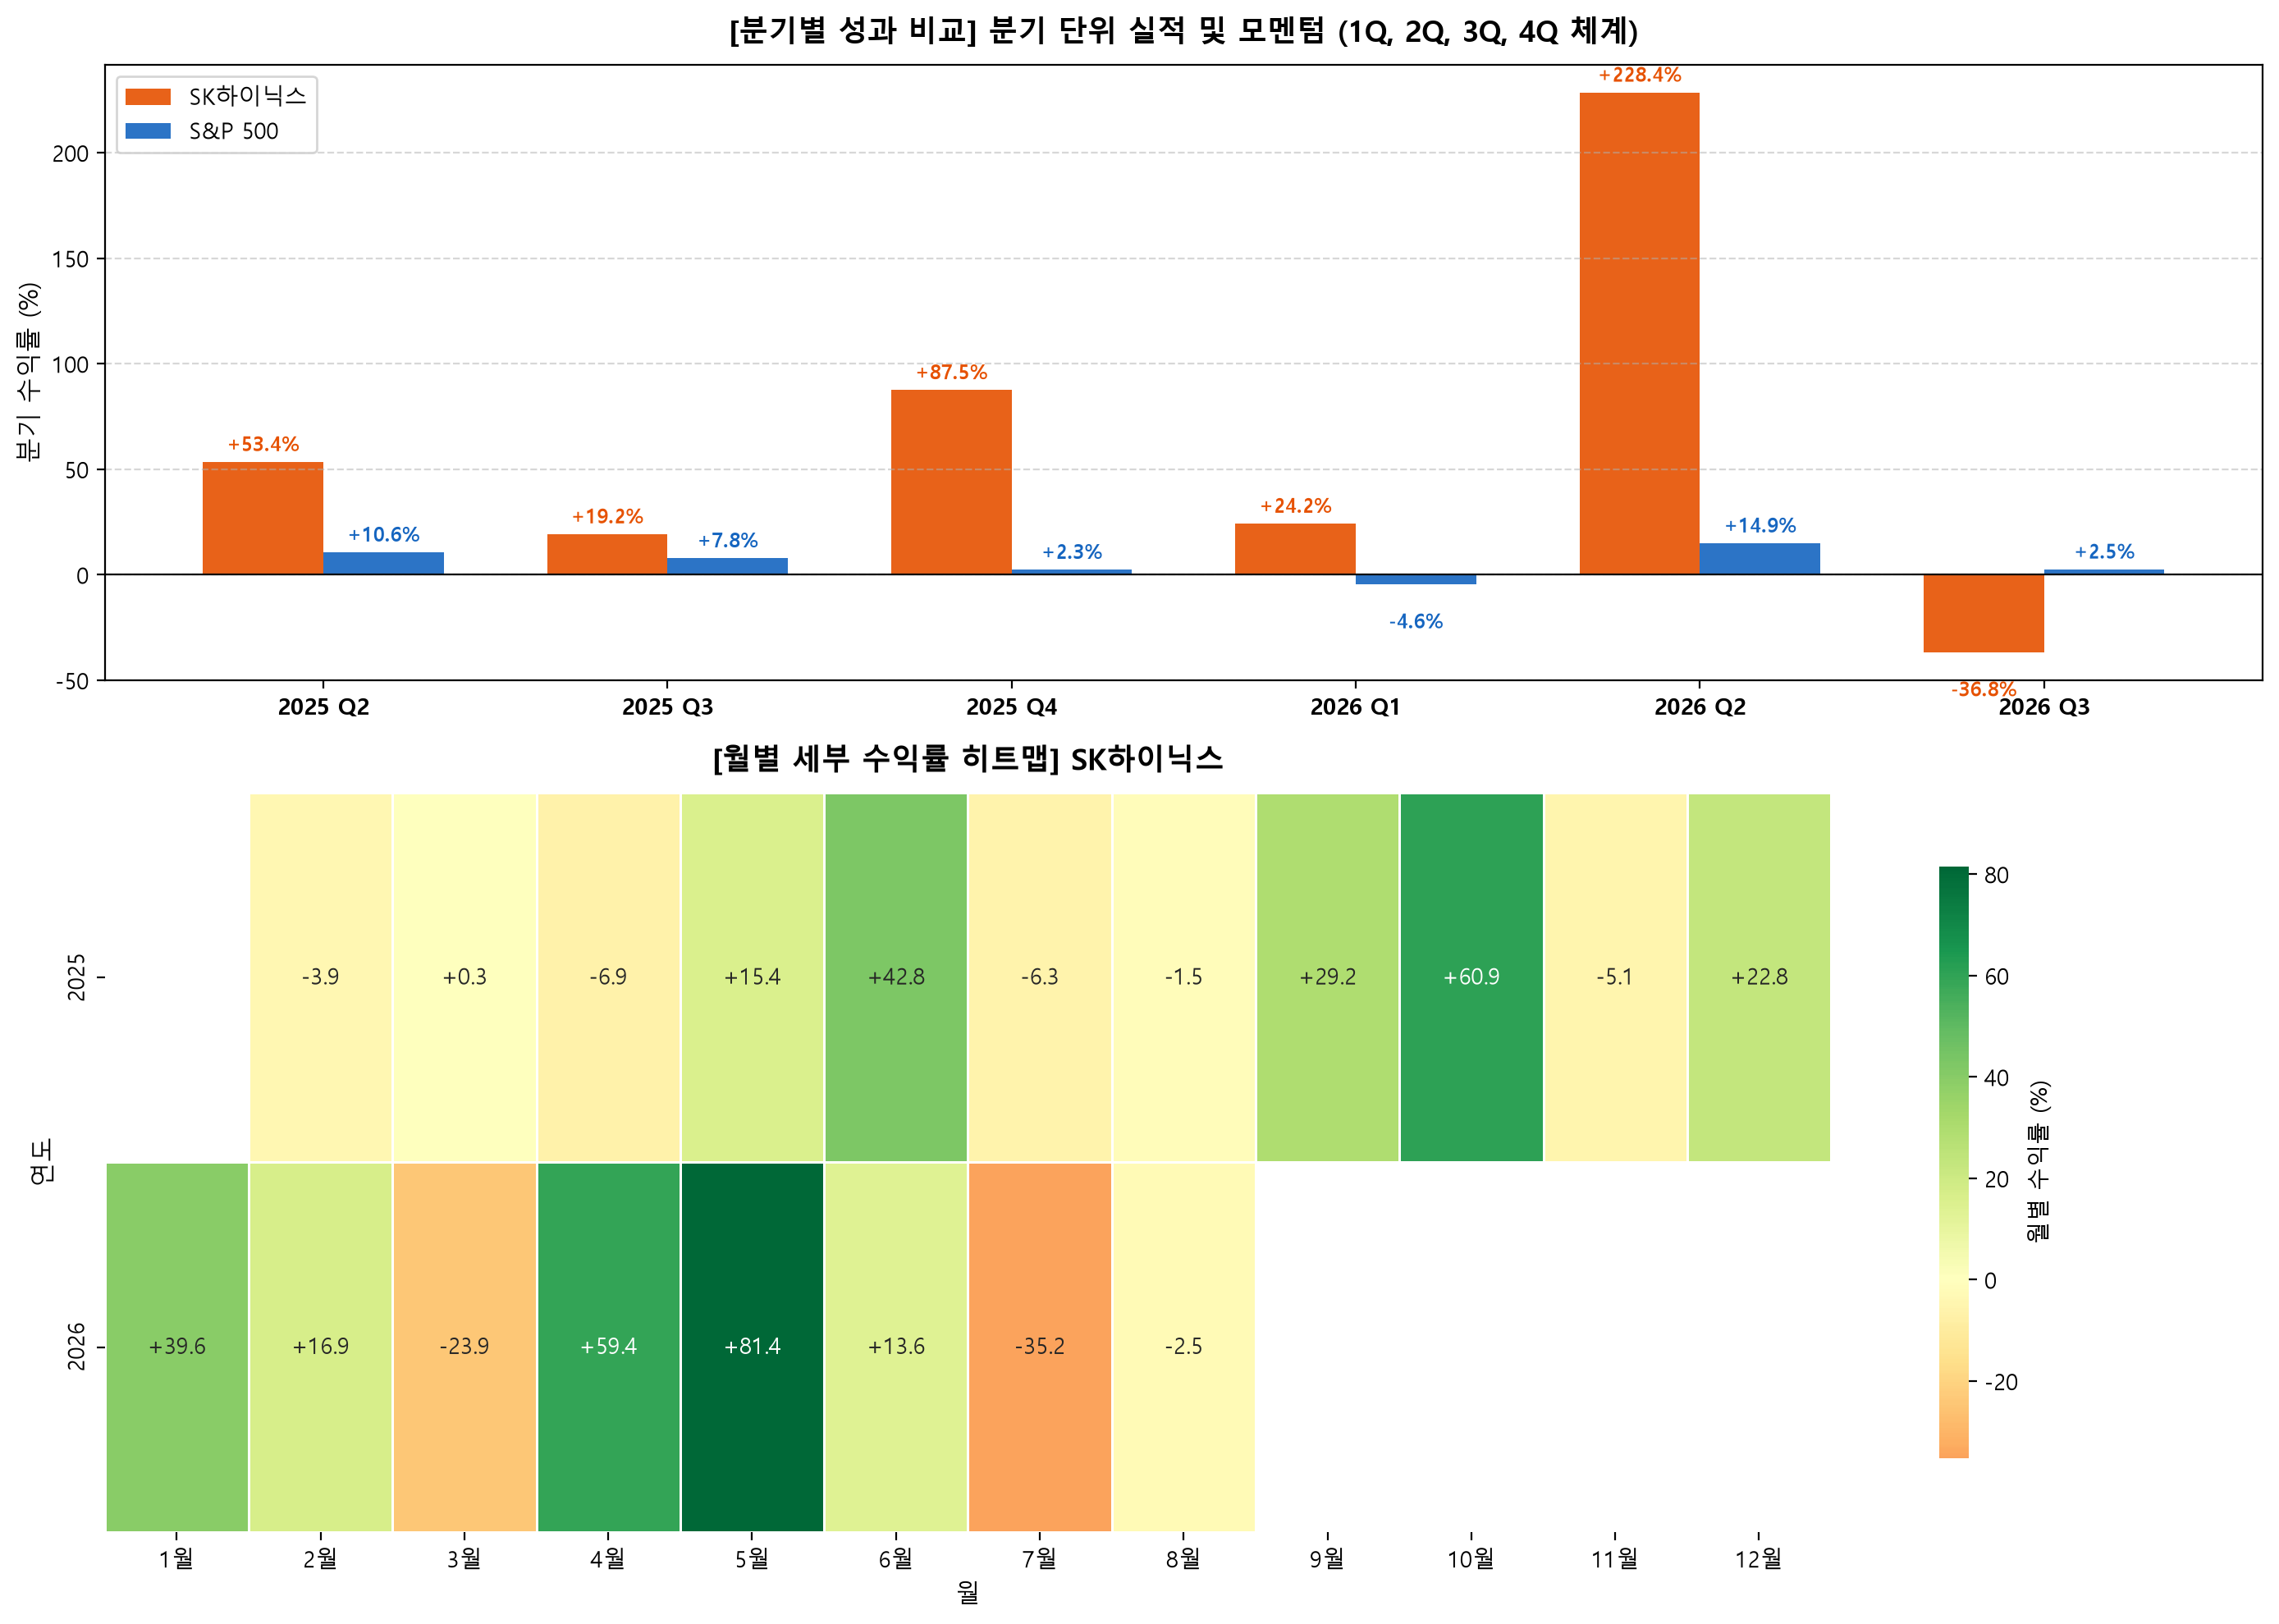

In [7]:
hyx_q = hyx_close.resample("QE").last().pct_change().dropna() * 100
sp_q  = sp_close.resample("QE").last().pct_change().dropna() * 100
common_q = hyx_q.index.intersection(sp_q.index)
q_labels = [f"{d.year} Q{(d.month-1)//3+1}" for d in common_q]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [1, 1.2]})

x = np.arange(len(q_labels))
w = 0.35
r1 = ax1.bar(x - w/2, hyx_q.loc[common_q].values, w, label="SK하이닉스", color=COLOR_HYX, alpha=0.9)
r2 = ax1.bar(x + w/2, sp_q.loc[common_q].values,  w, label="S&P 500",    color=COLOR_SP,  alpha=0.9)

for rect in r1:
    h = rect.get_height()
    ax1.annotate(f"{h:+.1f}%", (rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 3 if h >= 0 else -12), textcoords="offset points",
                 ha="center", va="bottom" if h >= 0 else "top", fontsize=9, fontweight="bold", color=COLOR_HYX)
for rect in r2:
    h = rect.get_height()
    ax1.annotate(f"{h:+.1f}%", (rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 3 if h >= 0 else -12), textcoords="offset points",
                 ha="center", va="bottom" if h >= 0 else "top", fontsize=9, fontweight="bold", color=COLOR_SP)

ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(q_labels, fontsize=10, fontweight="bold")
ax1.set_ylabel("분기 수익률 (%)")
ax1.set_title("[분기별 성과 비교] (1Q, 2Q, 3Q, 4Q 체계)", fontsize=13, fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.5, axis="y")
ax1.legend(loc="upper left")

hyx_m = hyx_close.resample("ME").last().pct_change().dropna() * 100
df_m = pd.DataFrame({"year": hyx_m.index.year, "month": hyx_m.index.month, "ret": hyx_m.values})
piv = df_m.pivot(index="year", columns="month", values="ret")
piv.columns = [f"{m}월" for m in piv.columns]

sns.heatmap(piv, ax=ax2, cmap="RdYlGn", center=0, annot=True, fmt="+.1f",
            linewidths=0.5, cbar_kws={"label": "월별 수익률 (%)", "shrink": 0.8})
ax2.set_title("[월별 세부 수익률 히트맵] SK하이닉스", fontsize=13, fontweight="bold")
ax2.set_xlabel("월")
ax2.set_ylabel("연도")

plt.tight_layout()
plt.savefig("images/03_monthly_return.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. 시각화 4 — STL 시계열 분해 (보너스 ①)

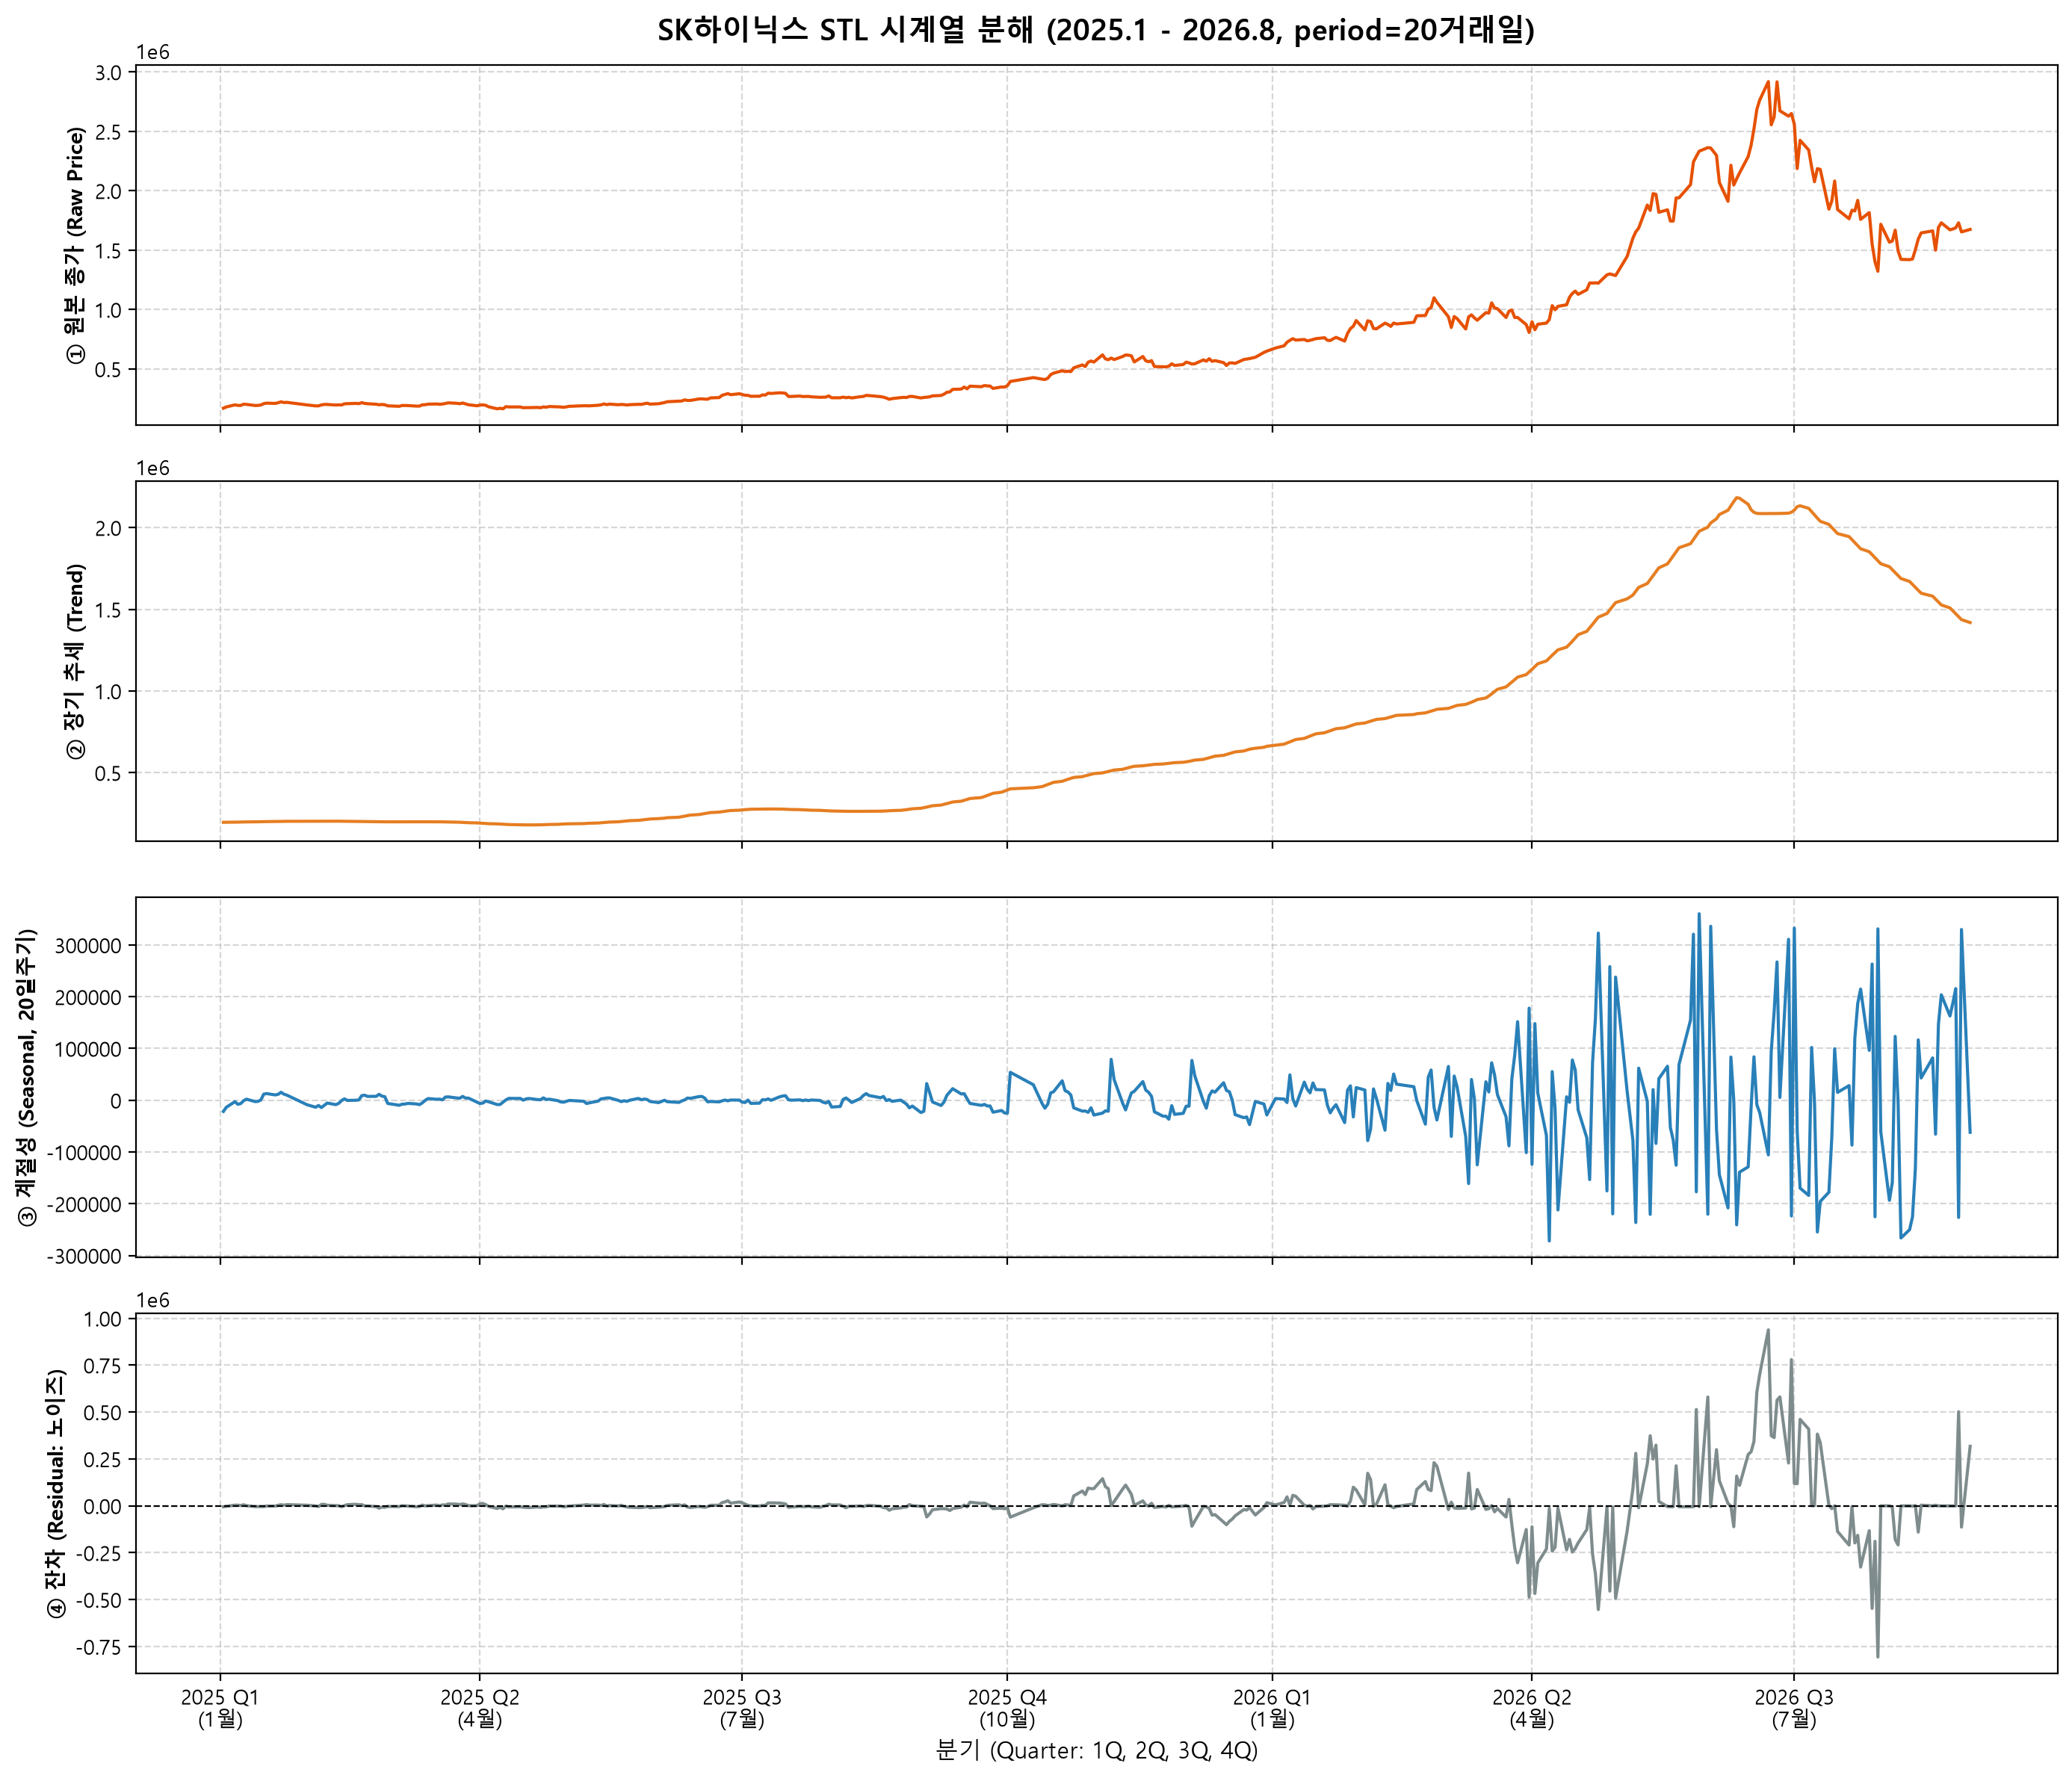

In [8]:
stl = STL(hyx_close, period=20, robust=True)
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
pairs = [
    (hyx_close,                                      "① 원본 종가 (Raw Price)",         COLOR_HYX),
    (pd.Series(res.trend,    index=hyx_close.index), "② 장기 추세 (Trend)",             "#E67E22"),
    (pd.Series(res.seasonal, index=hyx_close.index), "③ 계절성 (Seasonal, 20일주기)",  "#2980B9"),
    (pd.Series(res.resid,    index=hyx_close.index), "④ 잔차 (Residual: 노이즈)",       "#7F8C8D"),
]
for ax, (s, lbl, col) in zip(axes, pairs):
    ax.plot(s.index, s.values, color=col, linewidth=1.5)
    ax.set_ylabel(lbl, fontsize=10, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.5)
    if "잔차" in lbl: ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

axes[0].set_title("SK하이닉스 STL 시계열 분해 (2025.1 - 2026.8, period=20거래일)", fontsize=14, fontweight="bold")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
axes[-1].xaxis.set_major_formatter(plt.FuncFormatter(format_quarter))
axes[-1].set_xlabel("분기 (Quarter: 1Q, 2Q, 3Q, 4Q)")

plt.tight_layout()
plt.savefig("images/04_decomposition.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. 통계 요약 (2025-01-02 ~ 2026-08-31)

In [9]:
aligned = pd.DataFrame({"hyx": hyx_ret, "sp": sp_ret}).dropna()
corr = aligned["hyx"].corr(aligned["sp"])

summary = pd.DataFrame({
    "SK하이닉스": [
        f"{hyx_close.iloc[0]:,.0f} KRW",
        f"{hyx_close.iloc[-1]:,.0f} KRW",
        f"{(hyx_close.iloc[-1]/hyx_close.iloc[0]-1)*100:+.1f}%",
        f"{((hyx_close/hyx_close.cummax())-1).min()*100:.1f}%",
        f"{hyx_ret.std():.2f}%",
        f"{corr:.3f}",
        f"{len(hyx_close)}일"
    ],
    "S&P 500": [
        f"{sp_close.iloc[0]:,.2f} pt",
        f"{sp_close.iloc[-1]:,.2f} pt",
        f"{(sp_close.iloc[-1]/sp_close.iloc[0]-1)*100:+.1f}%",
        f"{((sp_close/sp_close.cummax())-1).min()*100:.1f}%",
        f"{sp_ret.std():.2f}%",
        f"{corr:.3f}",
        f"{len(sp_close)}일"
    ]
}, index=["시작가(2025.01)", "종가(2026.08.31)", "누적수익률", "MDD(최대낙폭)", "일간변동성", "상관계수", "거래일수"])

print("=== 분석 기간 요약 통계 (2025-01-02 ~ 2026-08-31) ===")
print(summary)

=== 분석 기간 요약 통계 (2025-01-02 ~ 2026-08-31) ===
                     SK하이닉스       S&P 500
시작가(2025.01)    169,050 KRW   5,868.55 pt
종가(2026.08.31) 1,674,000 KRW   7,686.14 pt
누적수익률               +890.2%        +31.0%
MDD(최대낙폭)             -54.7%        -18.9%
일간변동성                 4.91%         1.06%
상관계수                   0.096         0.096
거래일수                    403일          416일
